# Important: Restart Kernel Required
I have downgraded `numpy` to version 1.26.4 to resolve the compatibility issue with `pandas`.
**Please restart the kernel** (Kernel -> Restart Kernel) before running this notebook.

In [ ]:
import sys
import os
import importlib

# 1. Setup Paths
# Add py_TDA to path so we can import viz_style
sys.path.append(os.path.abspath("../../py_TDA"))

import viz_style
viz_style.set_architectural_style()

print("Paths set and style applied.")

Architectural plot style applied (Dark Mode).
Paths set and style applied.


In [ ]:
# 2. Load Session Data
from allensdk.brain_observatory.ecephys.ecephys_project_cache import EcephysProjectCache

output_dir = "../../Dataset/RAW"
manifest_path = os.path.join(output_dir, "manifest.json")
cache = EcephysProjectCache.from_warehouse(manifest=manifest_path)

# Use an available session ID (Update this if needed)
session_id = 715093703 
print(f"Loading Session {session_id}...")
session = cache.get_session_data(session_id)
print("Session loaded.")

Loading Session 715093703...
Session loaded.


Architectural plot style applied (Dark Mode).
Found regions: ['APN', 'DG', 'CA1', 'VISam', 'grey', 'VISpm', 'PO', 'LP', 'PoT', 'VISp', 'LGd', 'CA3', 'VISl', 'VISrl']

STARTING SIMPLE SKELETON PLOT FOR: APN
Saved simple skeleton to: ../Results/TDA_Iteration/4_1Simple_Manifold_Skeleton/APN.png


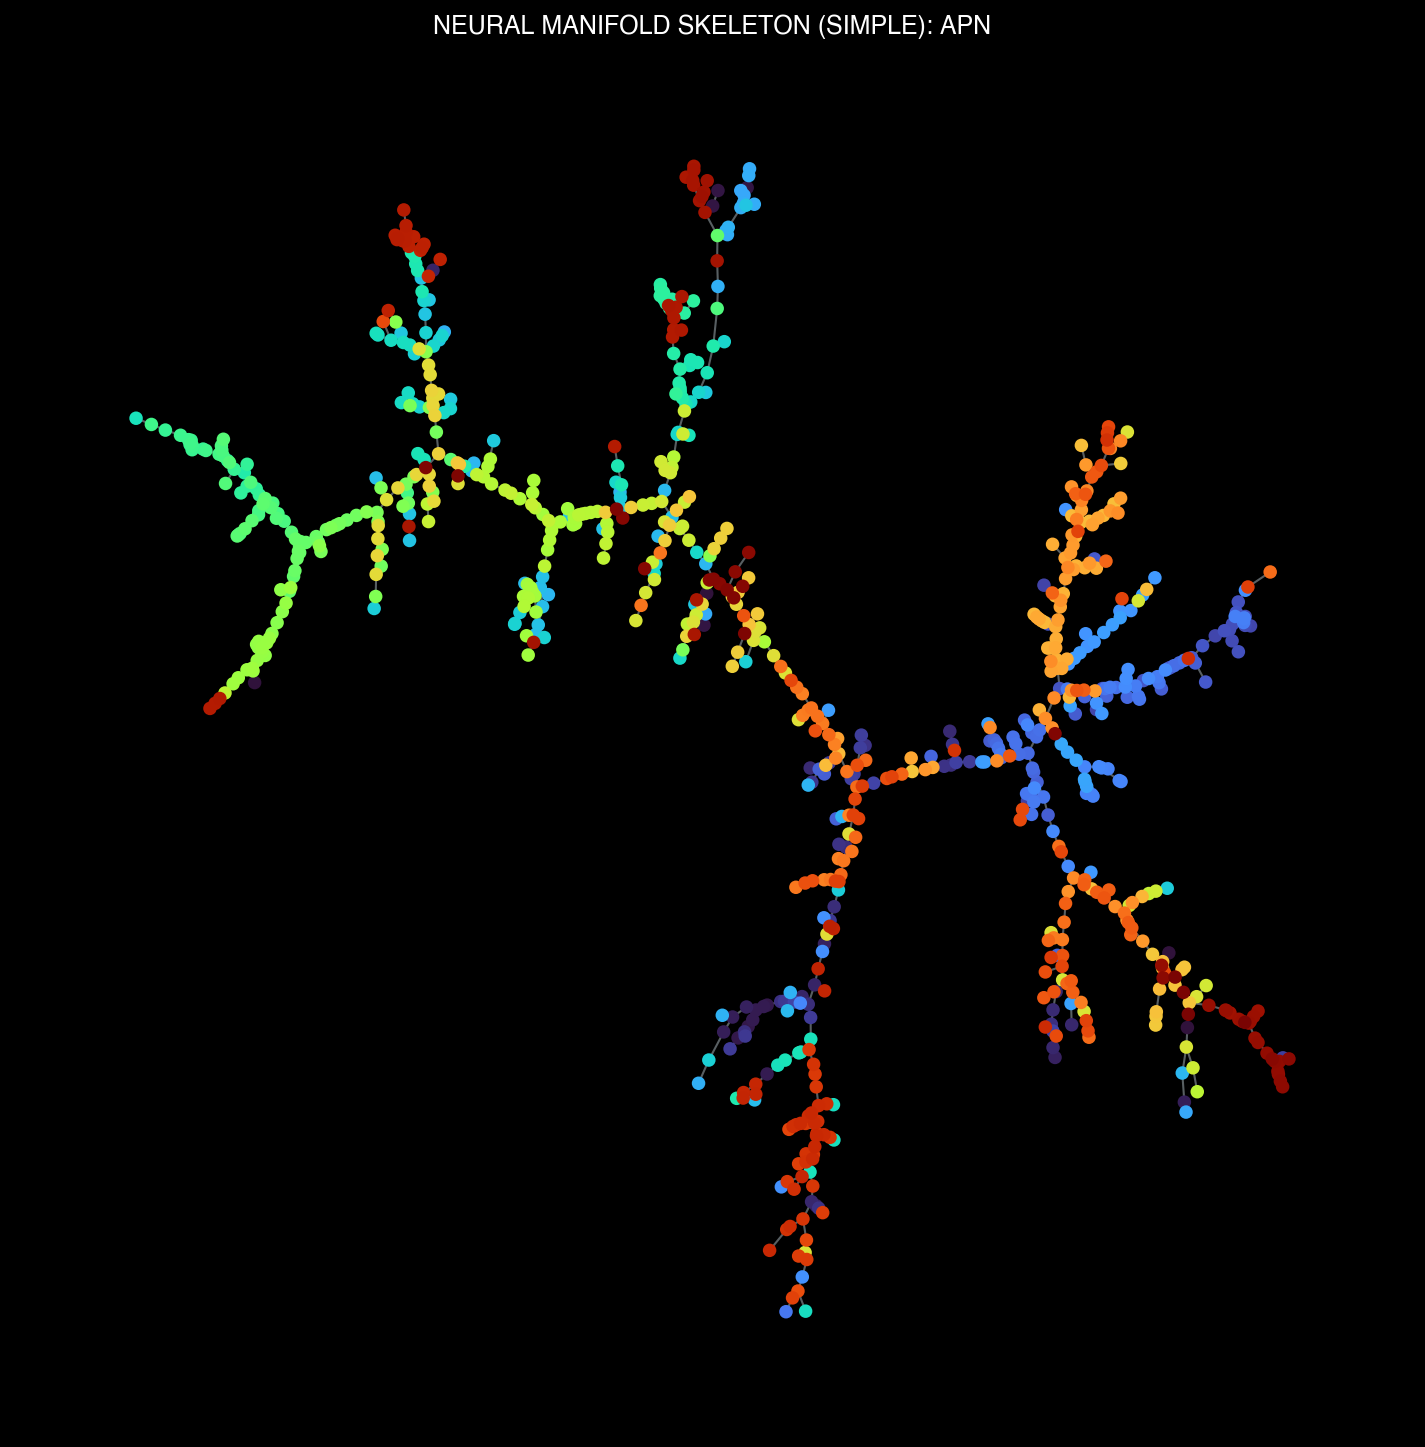


STARTING SIMPLE SKELETON PLOT FOR: DG
Saved simple skeleton to: ../Results/TDA_Iteration/4_1Simple_Manifold_Skeleton/DG.png


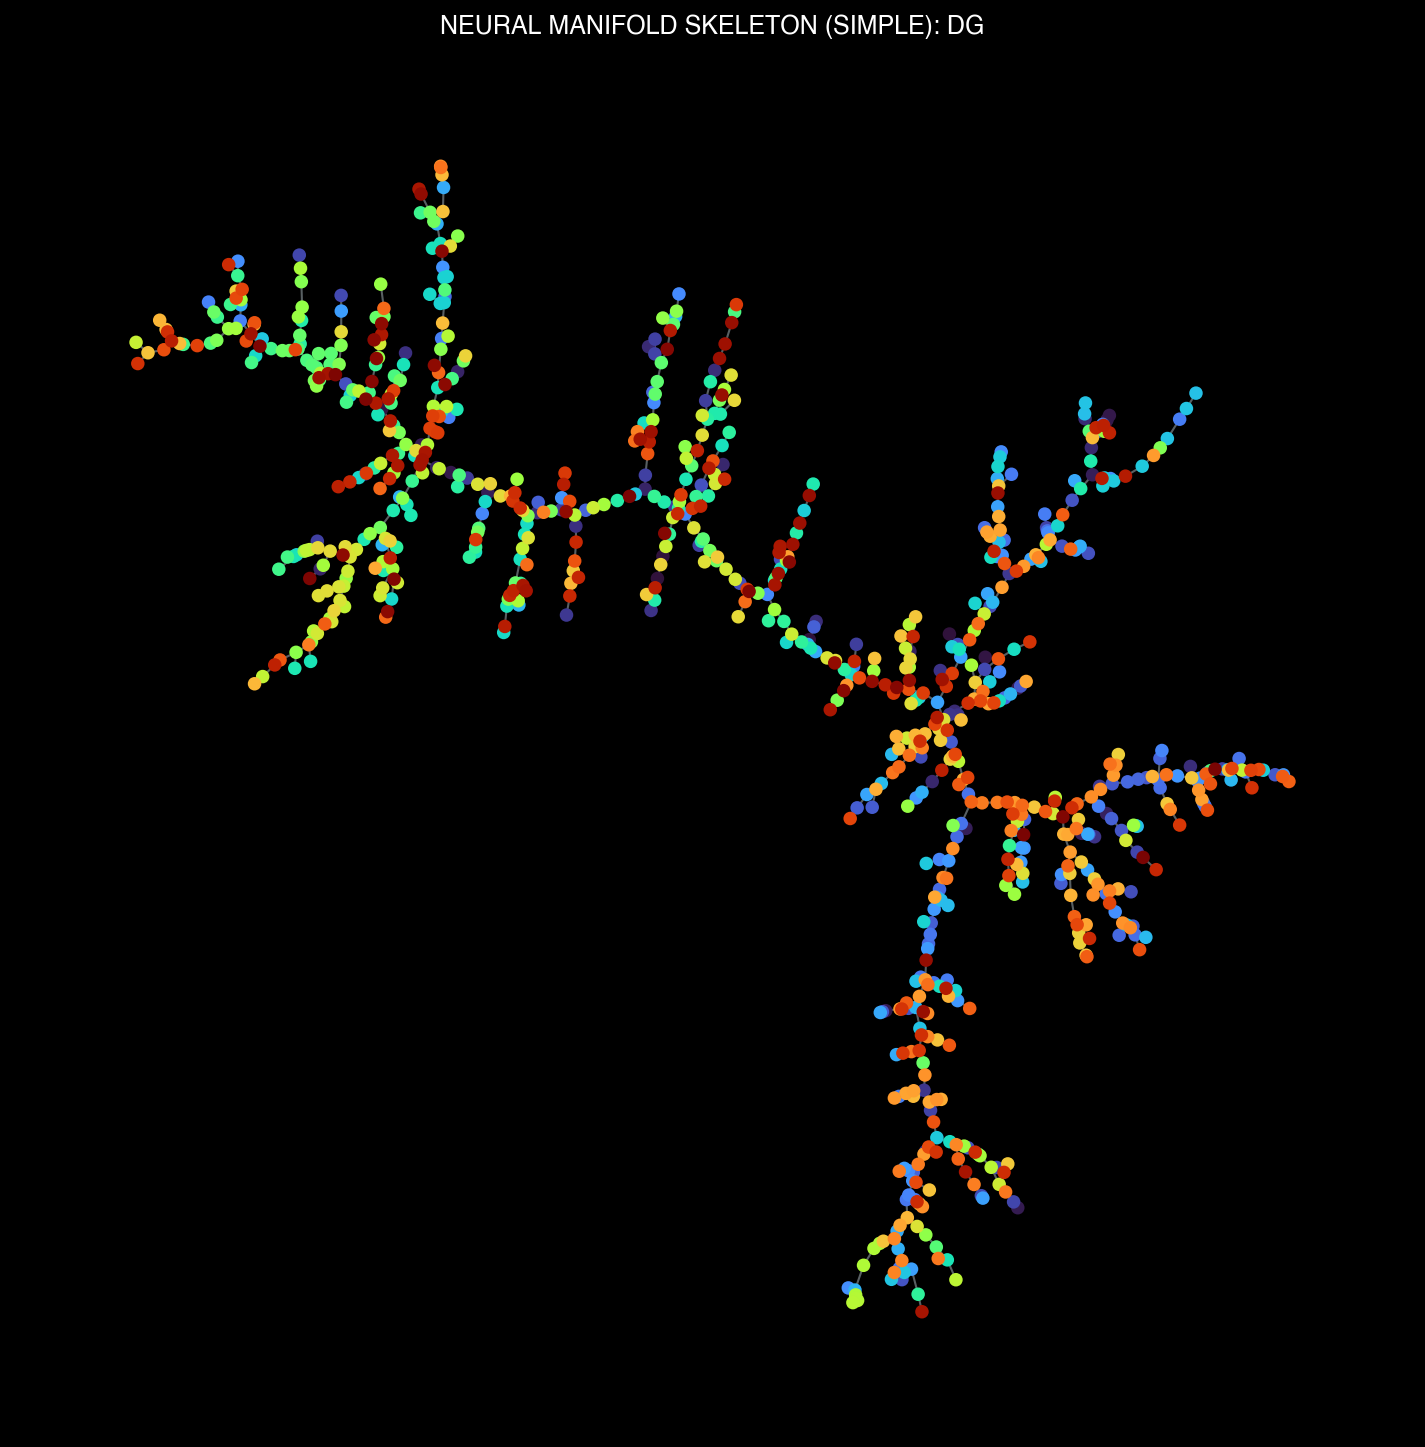


STARTING SIMPLE SKELETON PLOT FOR: CA1
Saved simple skeleton to: ../Results/TDA_Iteration/4_1Simple_Manifold_Skeleton/CA1.png


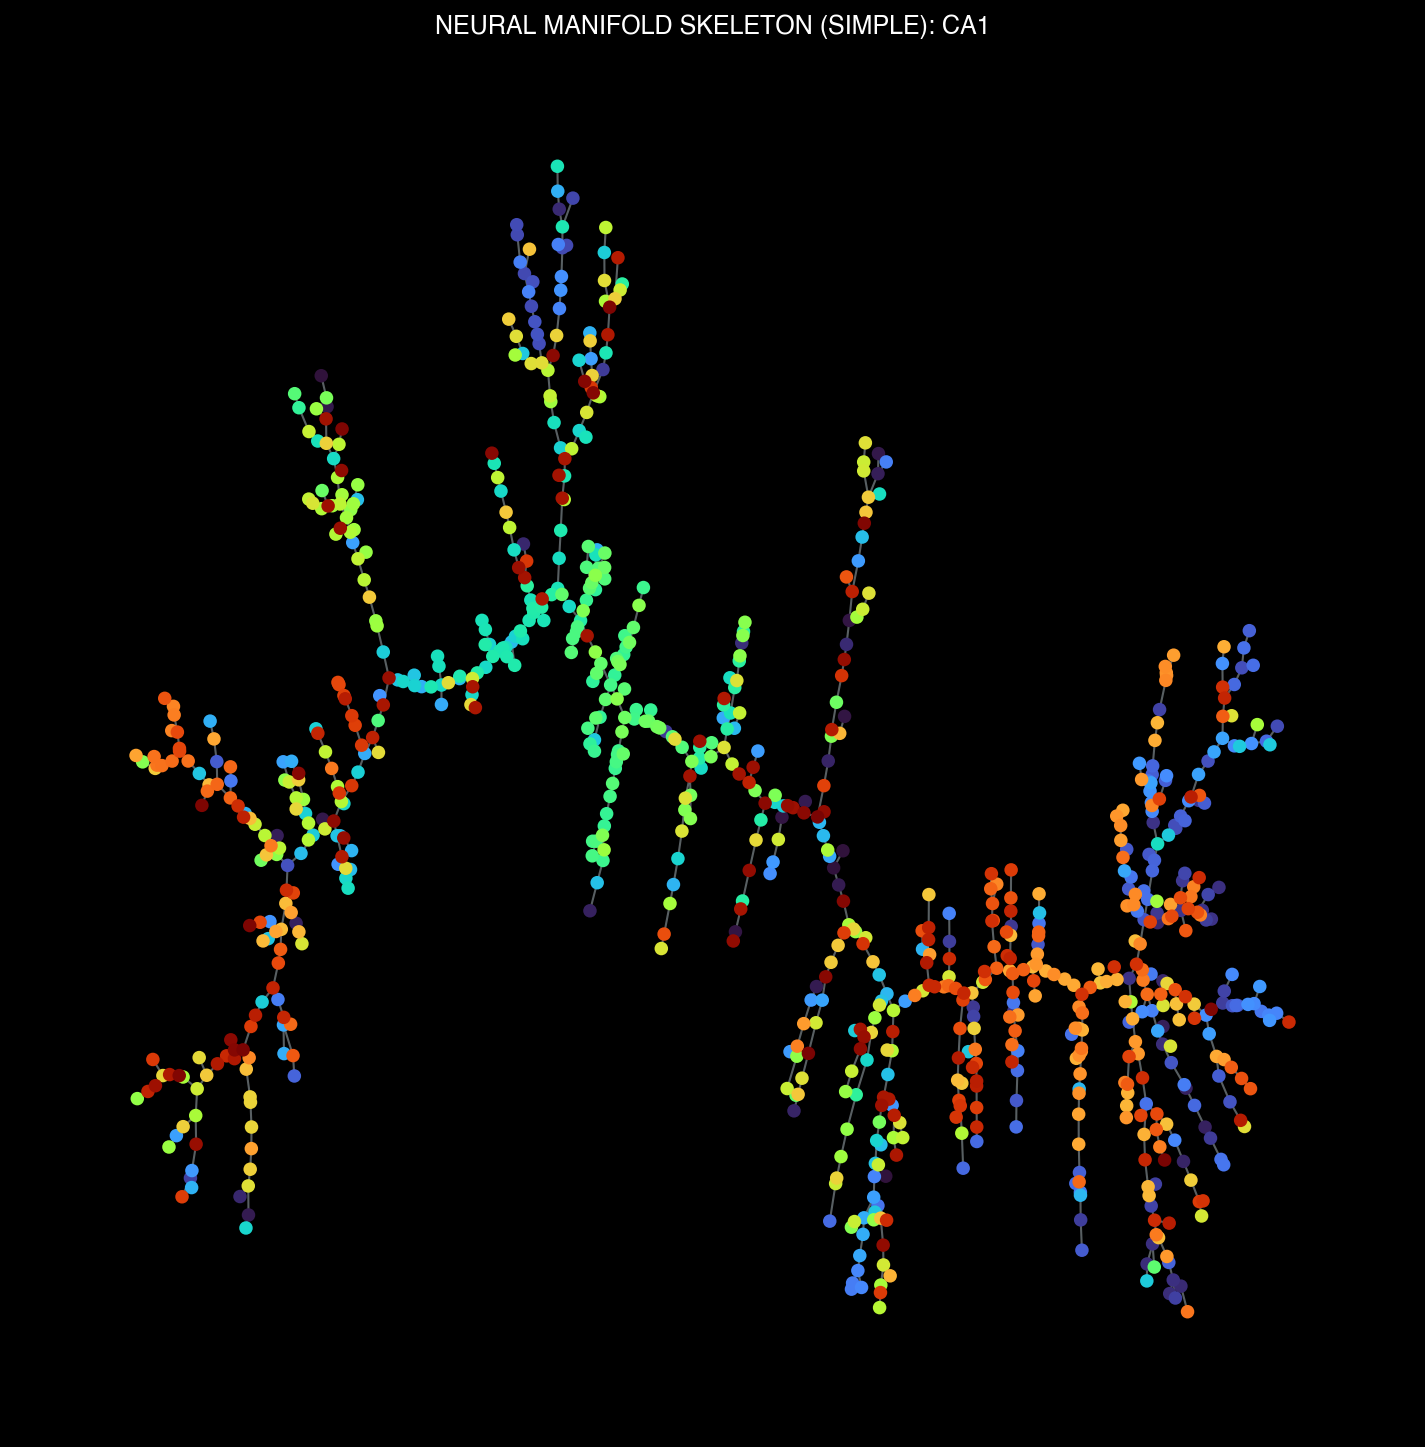


STARTING SIMPLE SKELETON PLOT FOR: VISam
Error processing VISam: [Errno 2] No such file or directory: '../Results/TDA_Iteration/4_1Simple_Manifold_Skeleton/VISam.png'

STARTING SIMPLE SKELETON PLOT FOR: grey
Saved simple skeleton to: ../Results/TDA_Iteration/4_1Simple_Manifold_Skeleton/grey.png


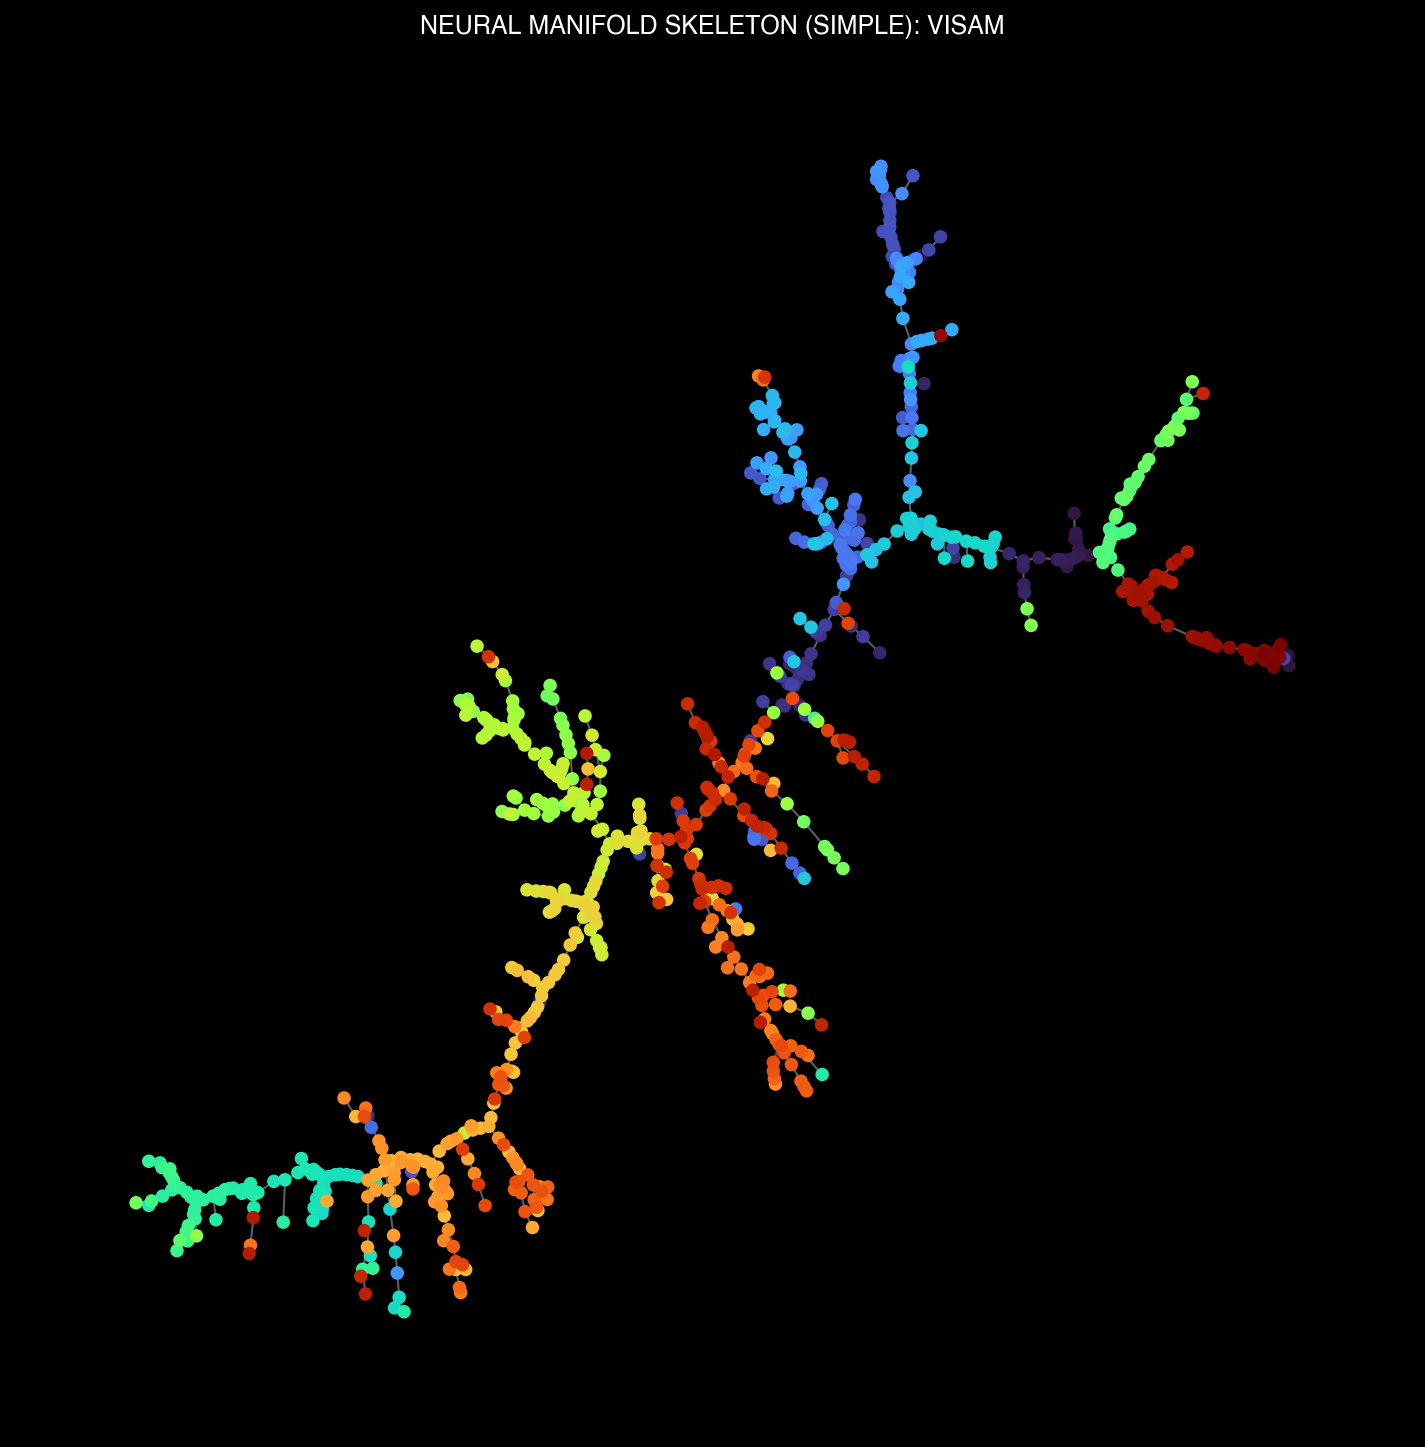

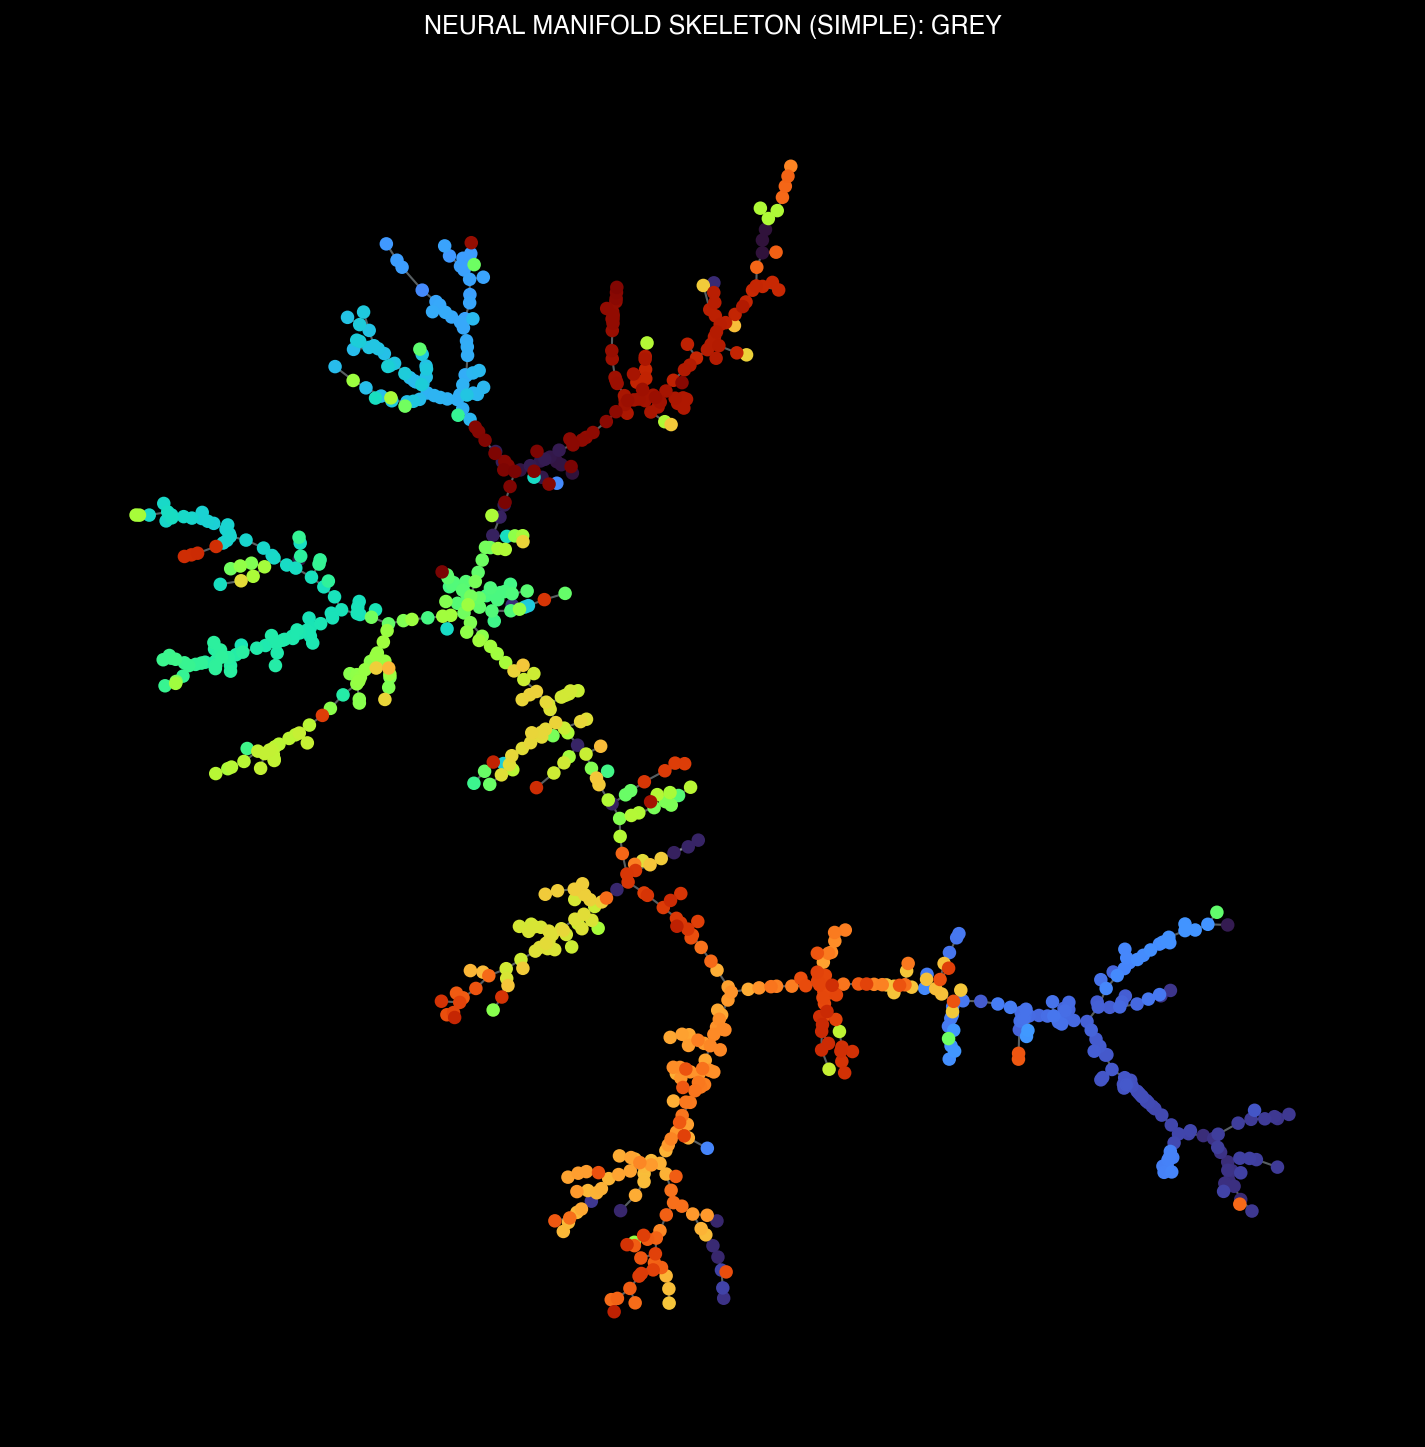


STARTING SIMPLE SKELETON PLOT FOR: VISpm
Saved simple skeleton to: ../Results/TDA_Iteration/4_1Simple_Manifold_Skeleton/VISpm.png


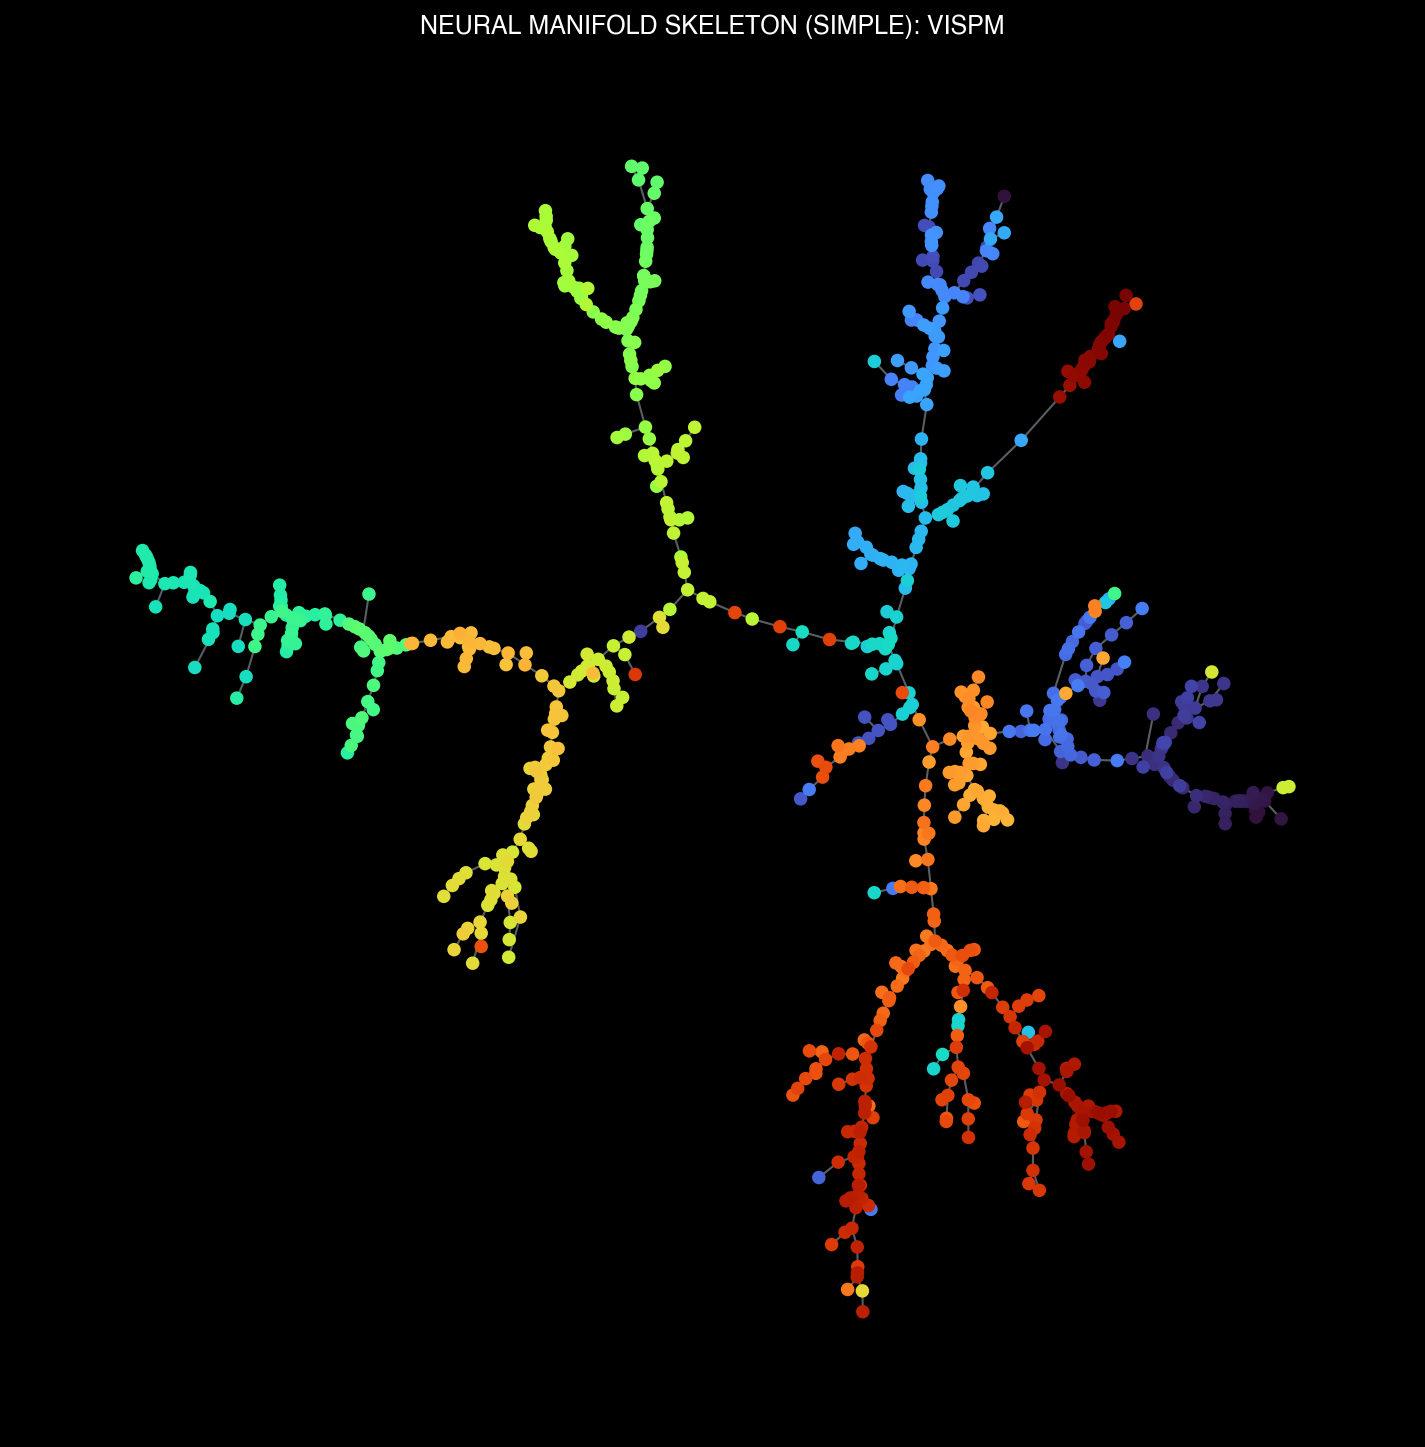


STARTING SIMPLE SKELETON PLOT FOR: PO
Saved simple skeleton to: ../Results/TDA_Iteration/4_1Simple_Manifold_Skeleton/PO.png


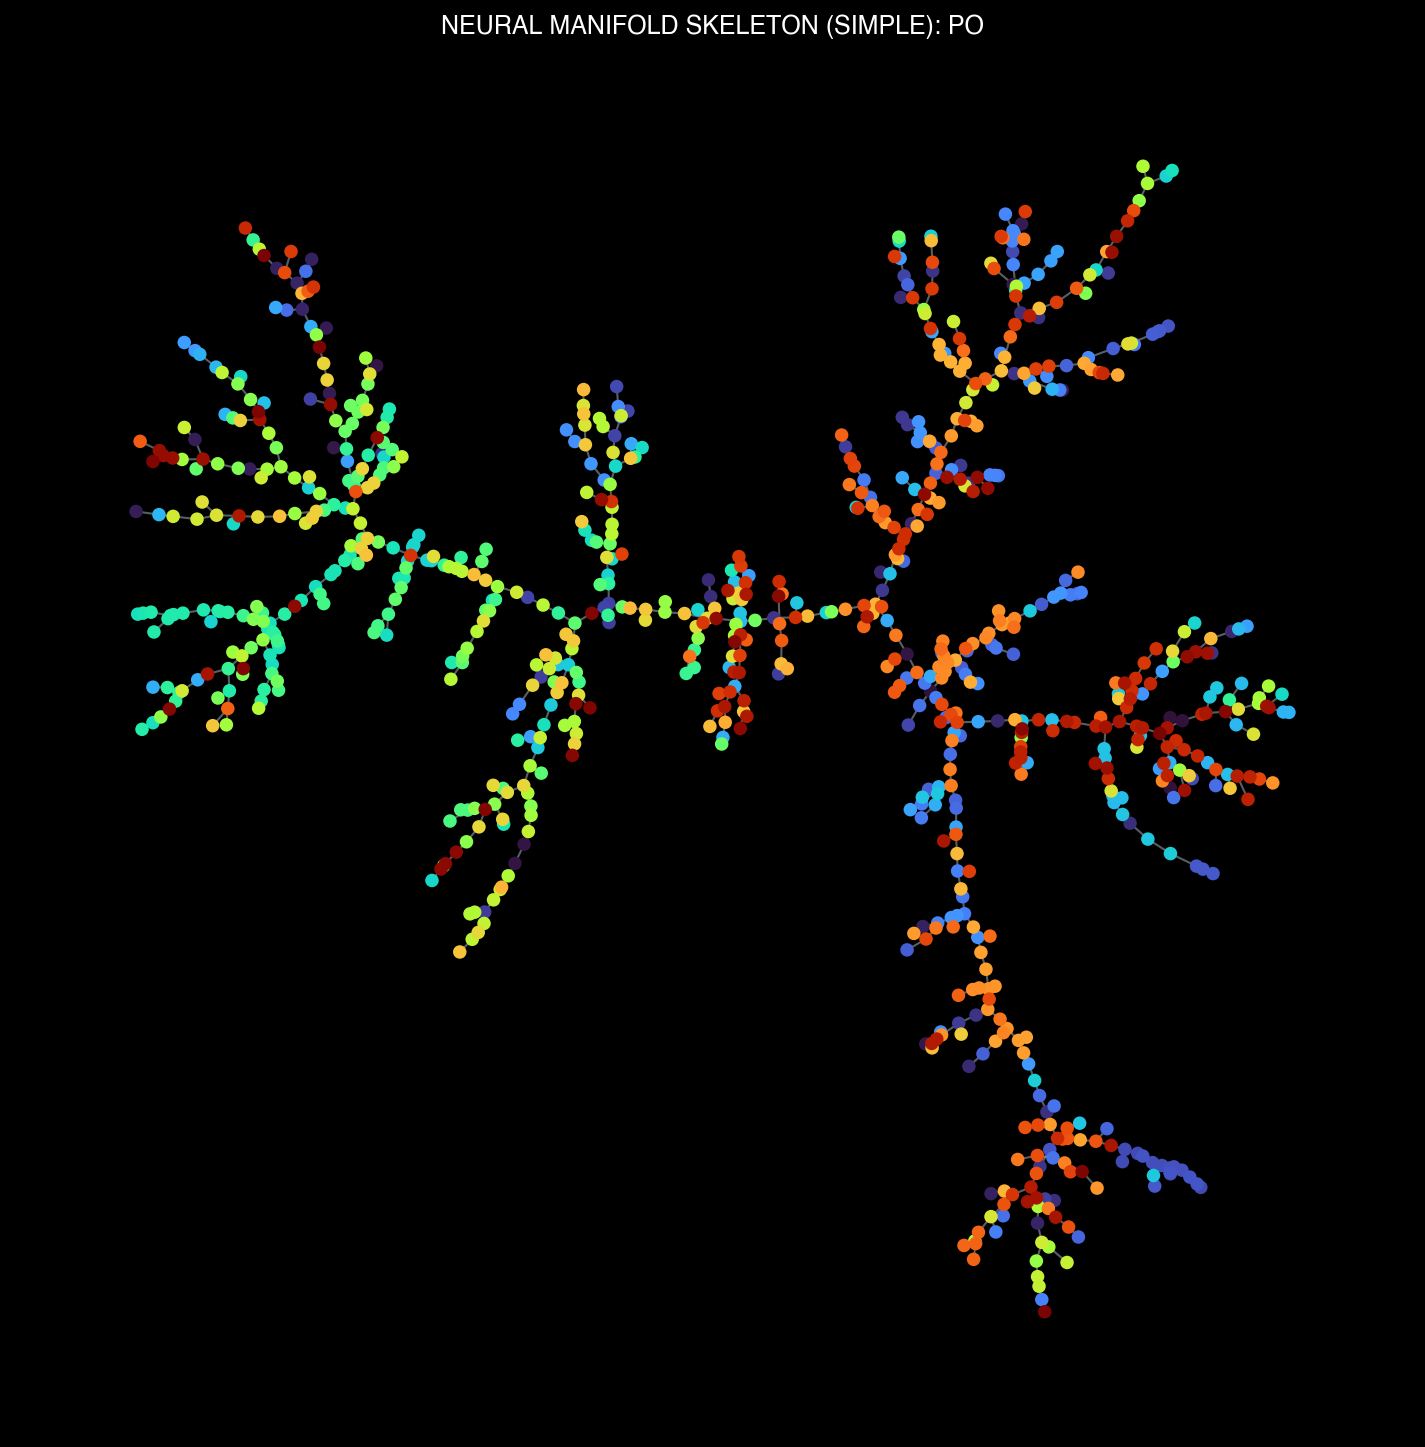


STARTING SIMPLE SKELETON PLOT FOR: LP
Saved simple skeleton to: ../Results/TDA_Iteration/4_1Simple_Manifold_Skeleton/LP.png


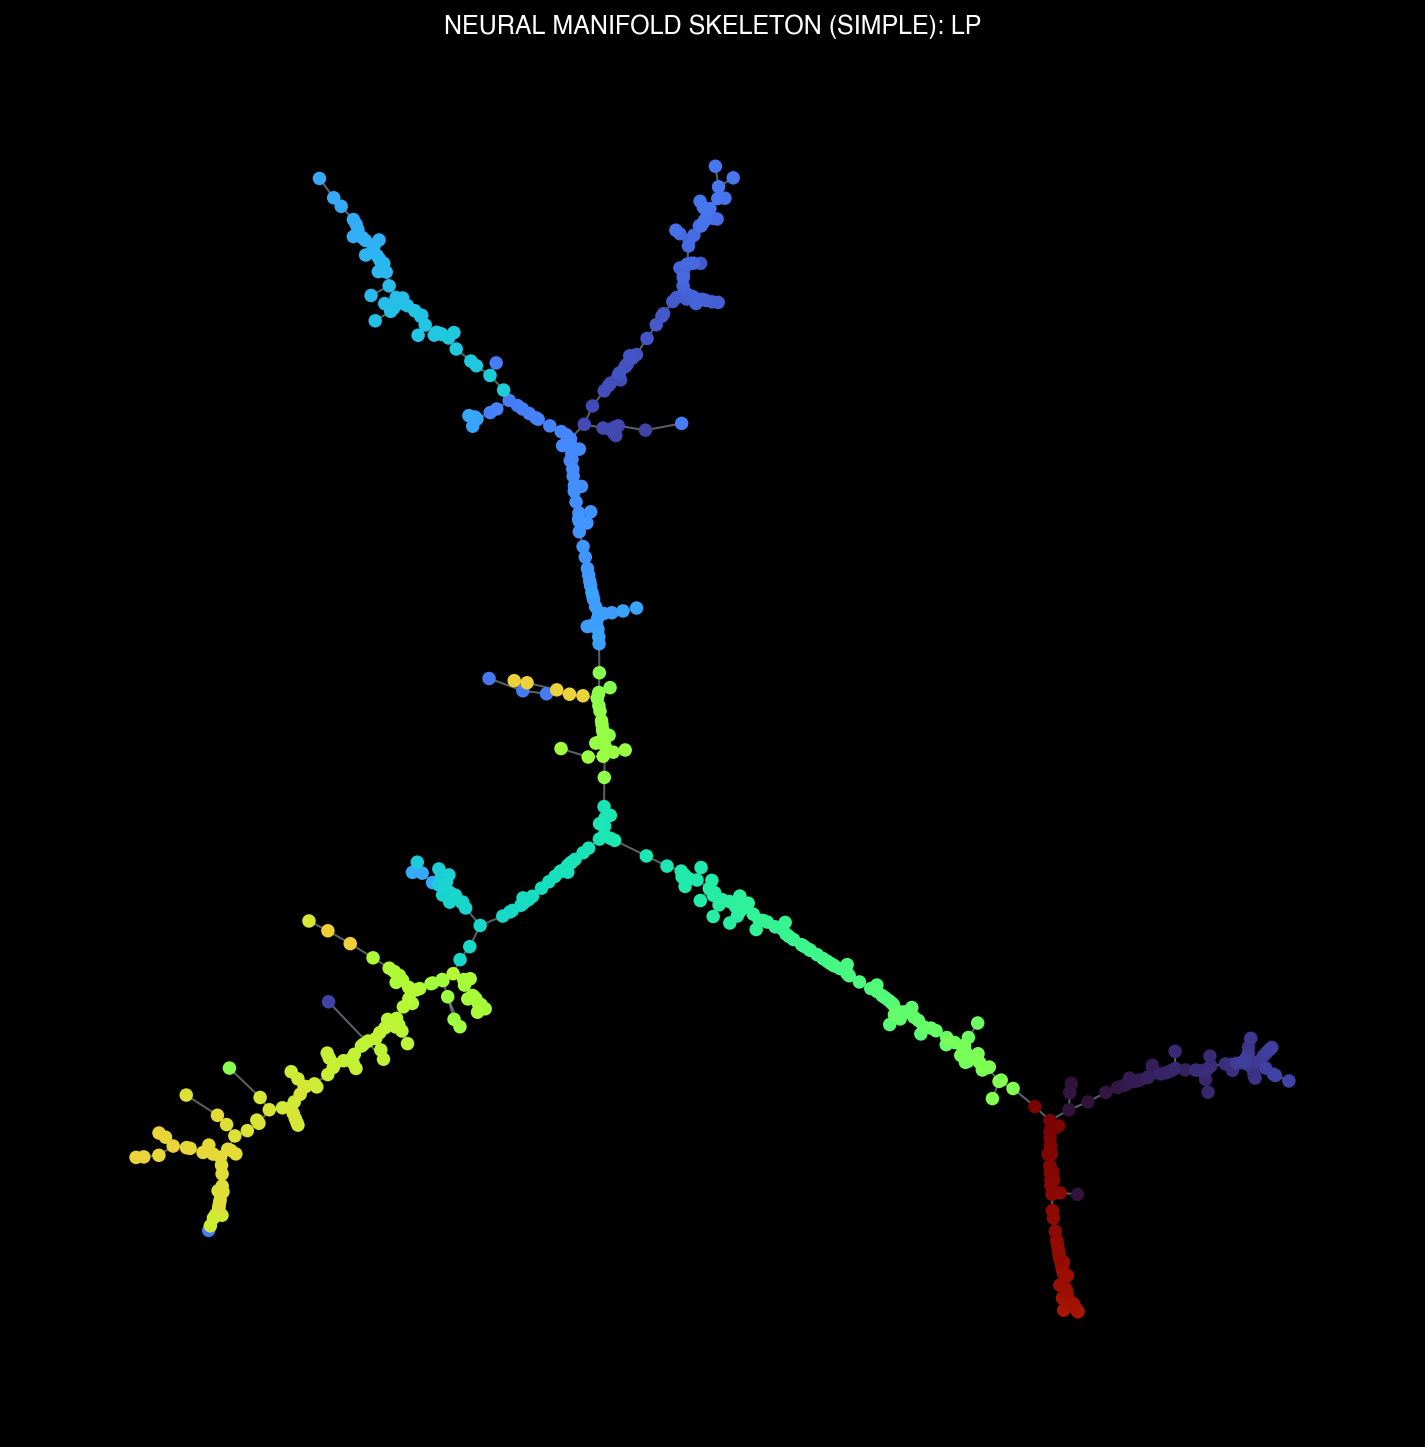


STARTING SIMPLE SKELETON PLOT FOR: PoT
Skipping PoT: Not enough units (<10).

STARTING SIMPLE SKELETON PLOT FOR: VISp
Saved simple skeleton to: ../Results/TDA_Iteration/4_1Simple_Manifold_Skeleton/VISp.png


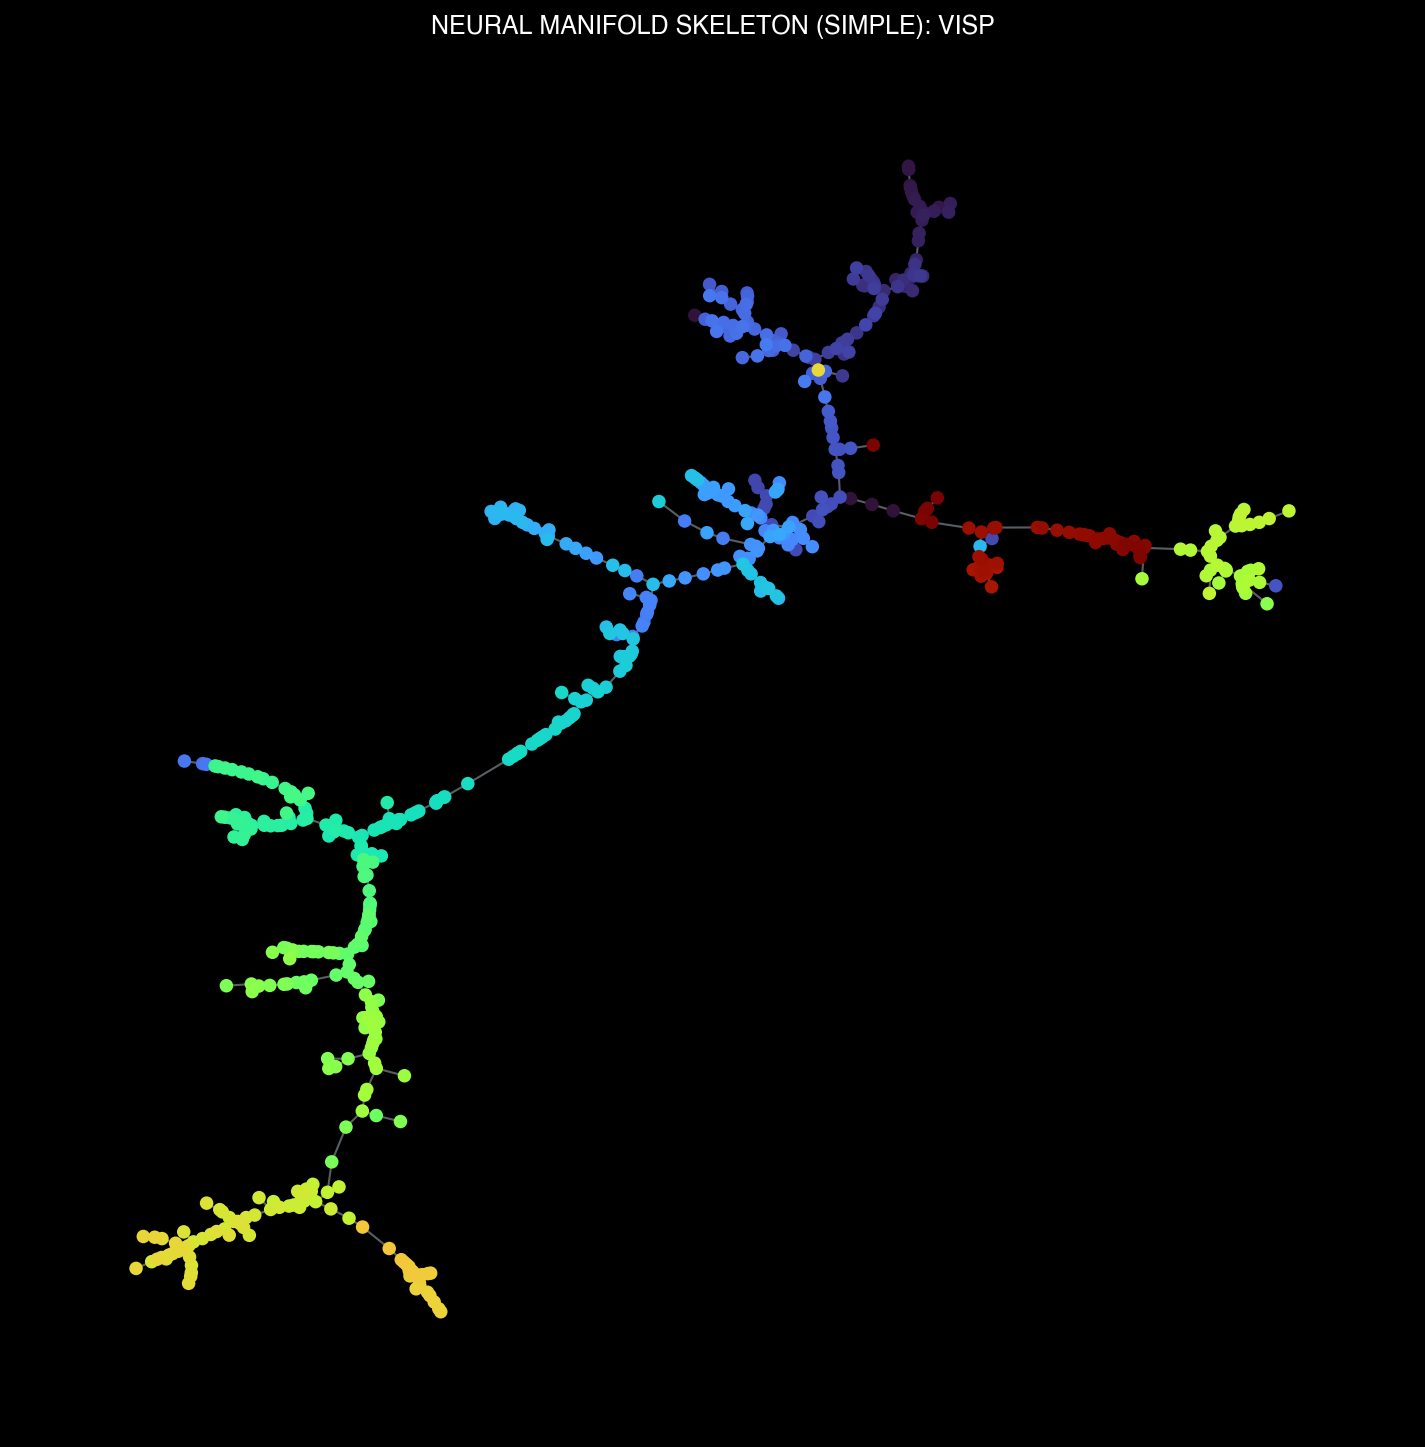


STARTING SIMPLE SKELETON PLOT FOR: LGd
Saved simple skeleton to: ../Results/TDA_Iteration/4_1Simple_Manifold_Skeleton/LGd.png


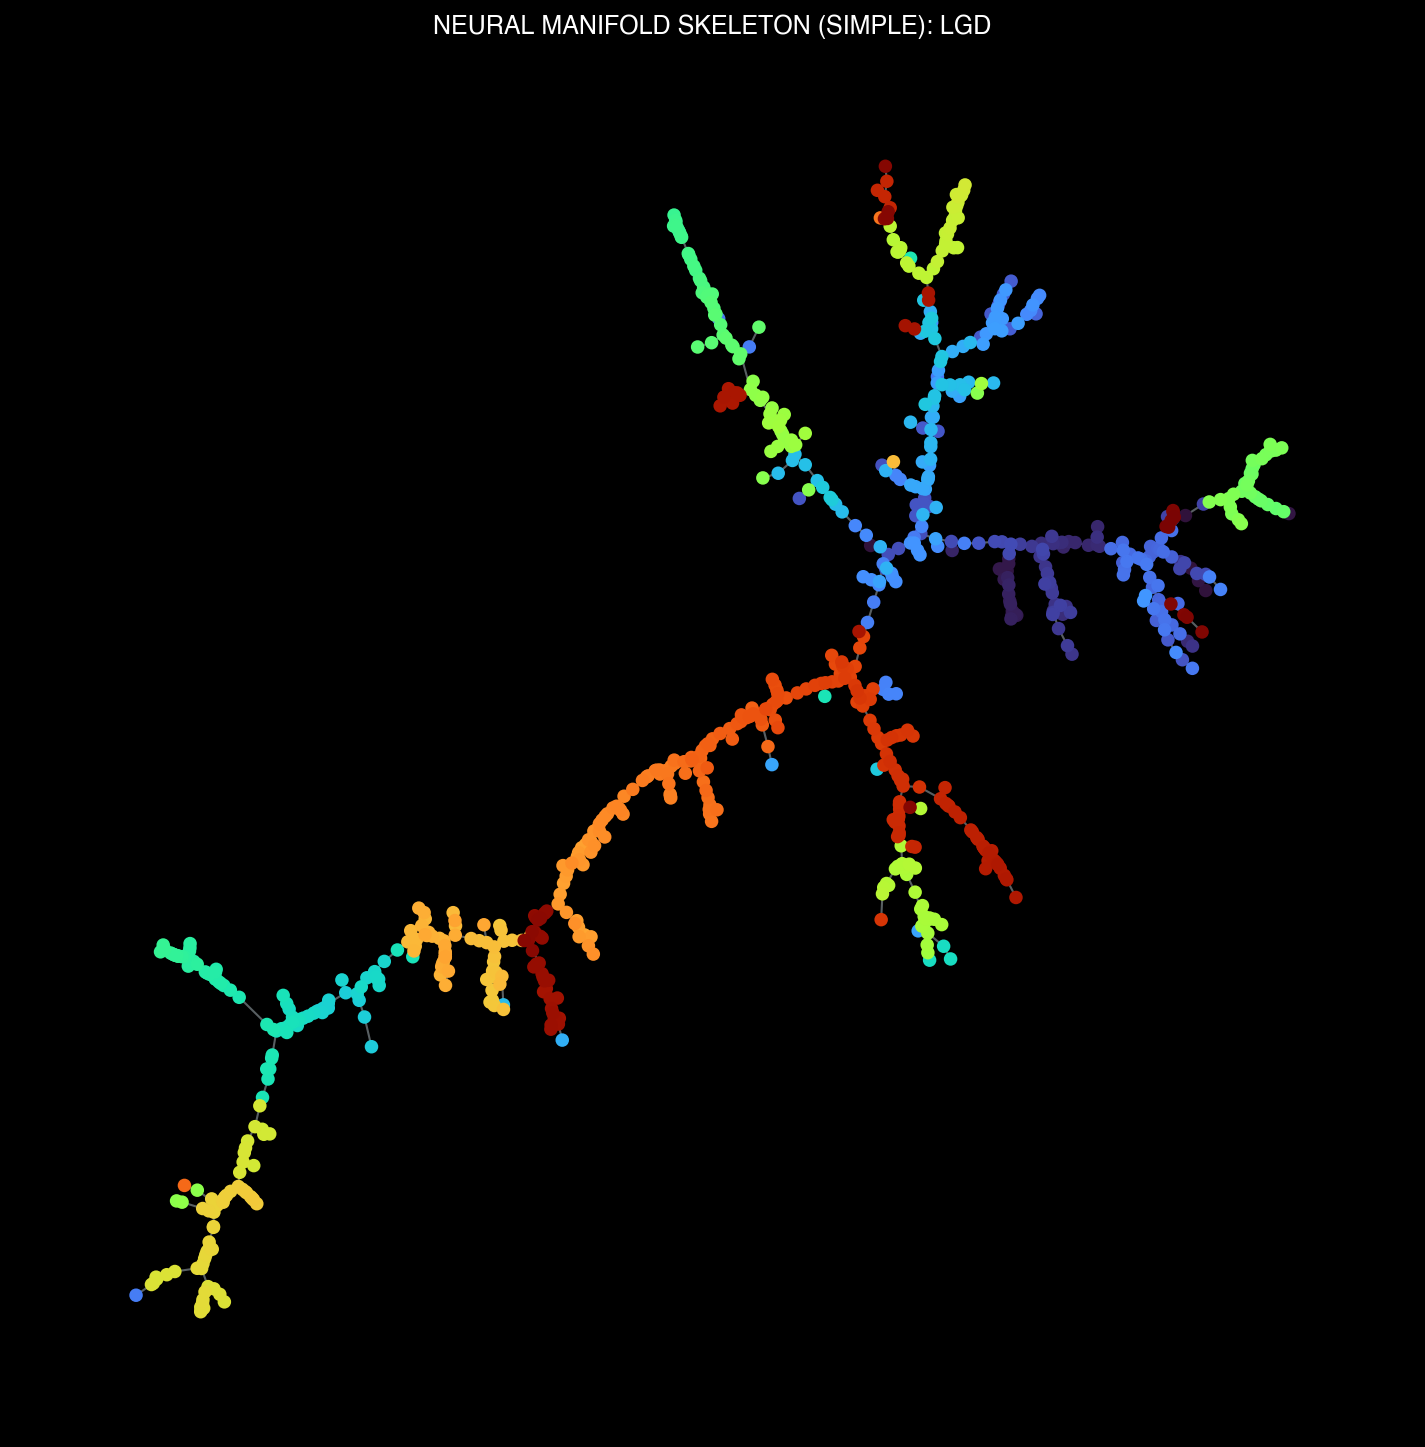


STARTING SIMPLE SKELETON PLOT FOR: CA3
Saved simple skeleton to: ../Results/TDA_Iteration/4_1Simple_Manifold_Skeleton/CA3.png


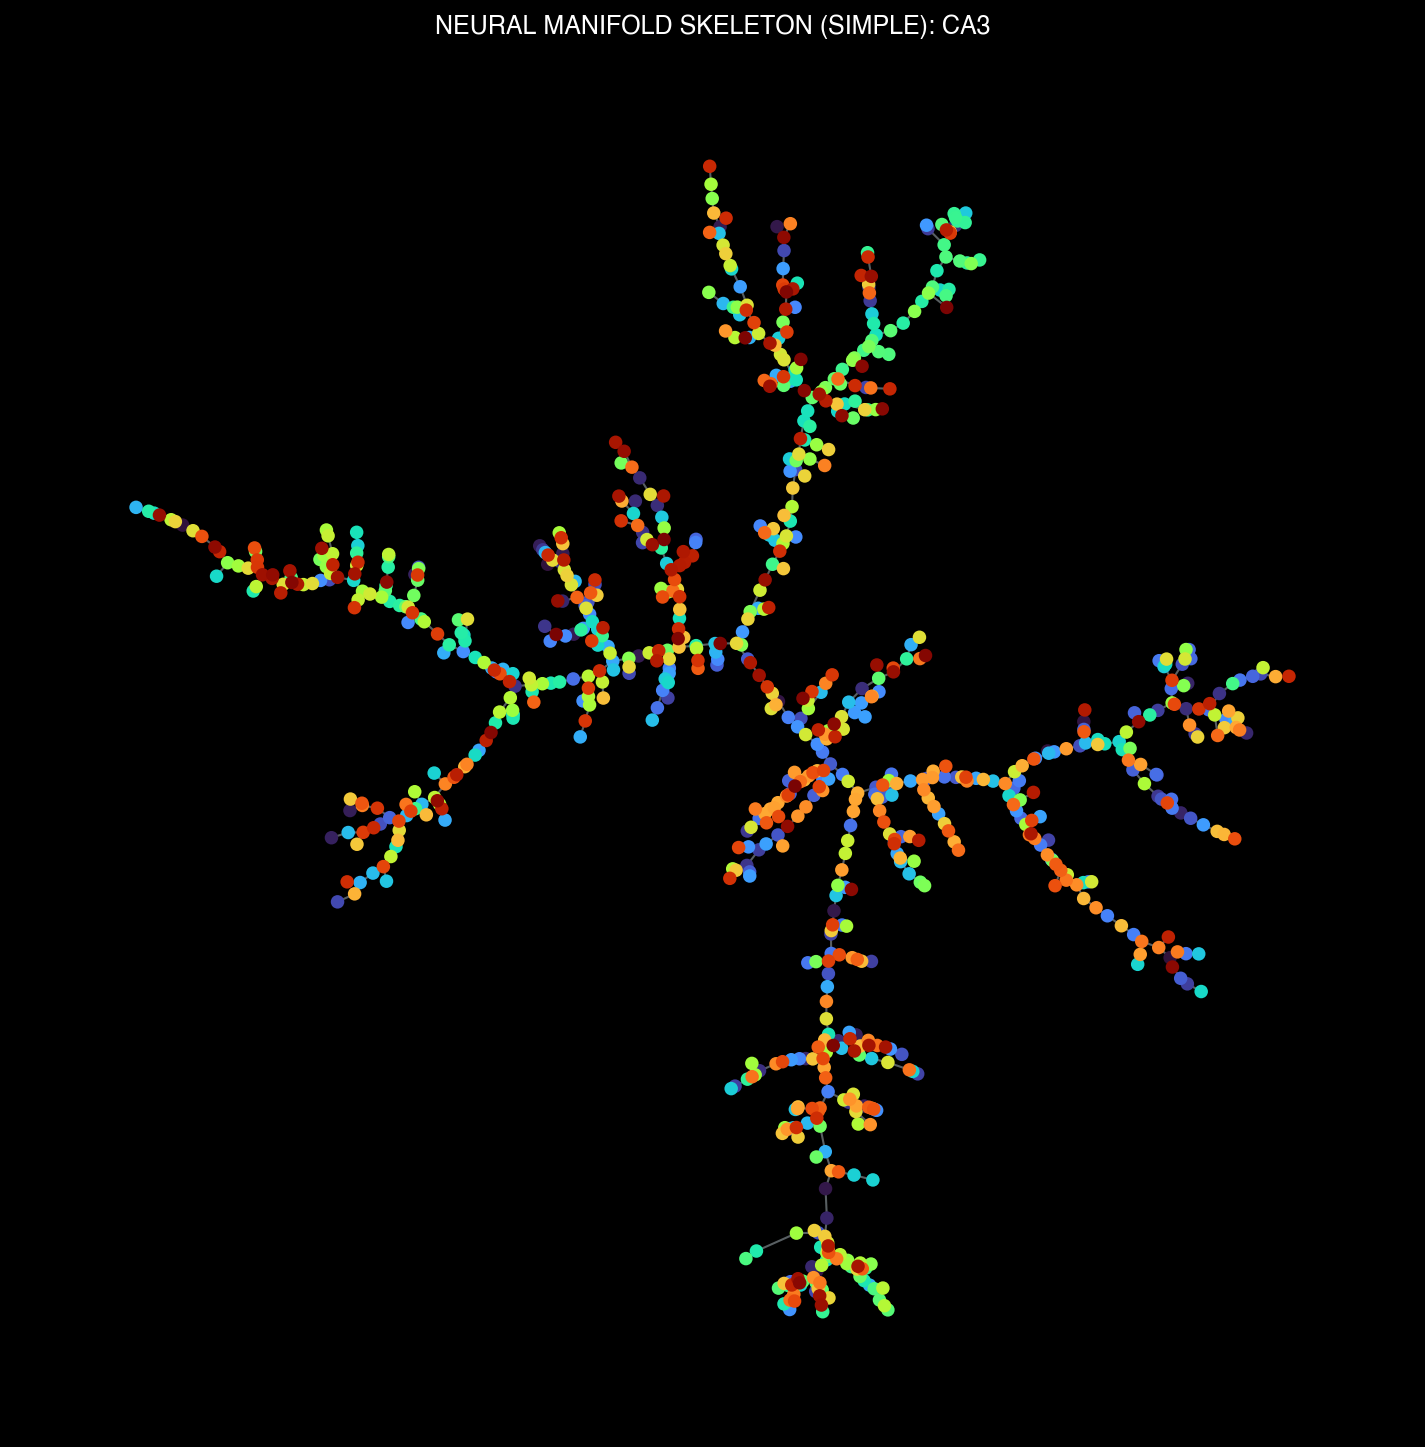


STARTING SIMPLE SKELETON PLOT FOR: VISl
Saved simple skeleton to: ../Results/TDA_Iteration/4_1Simple_Manifold_Skeleton/VISl.png


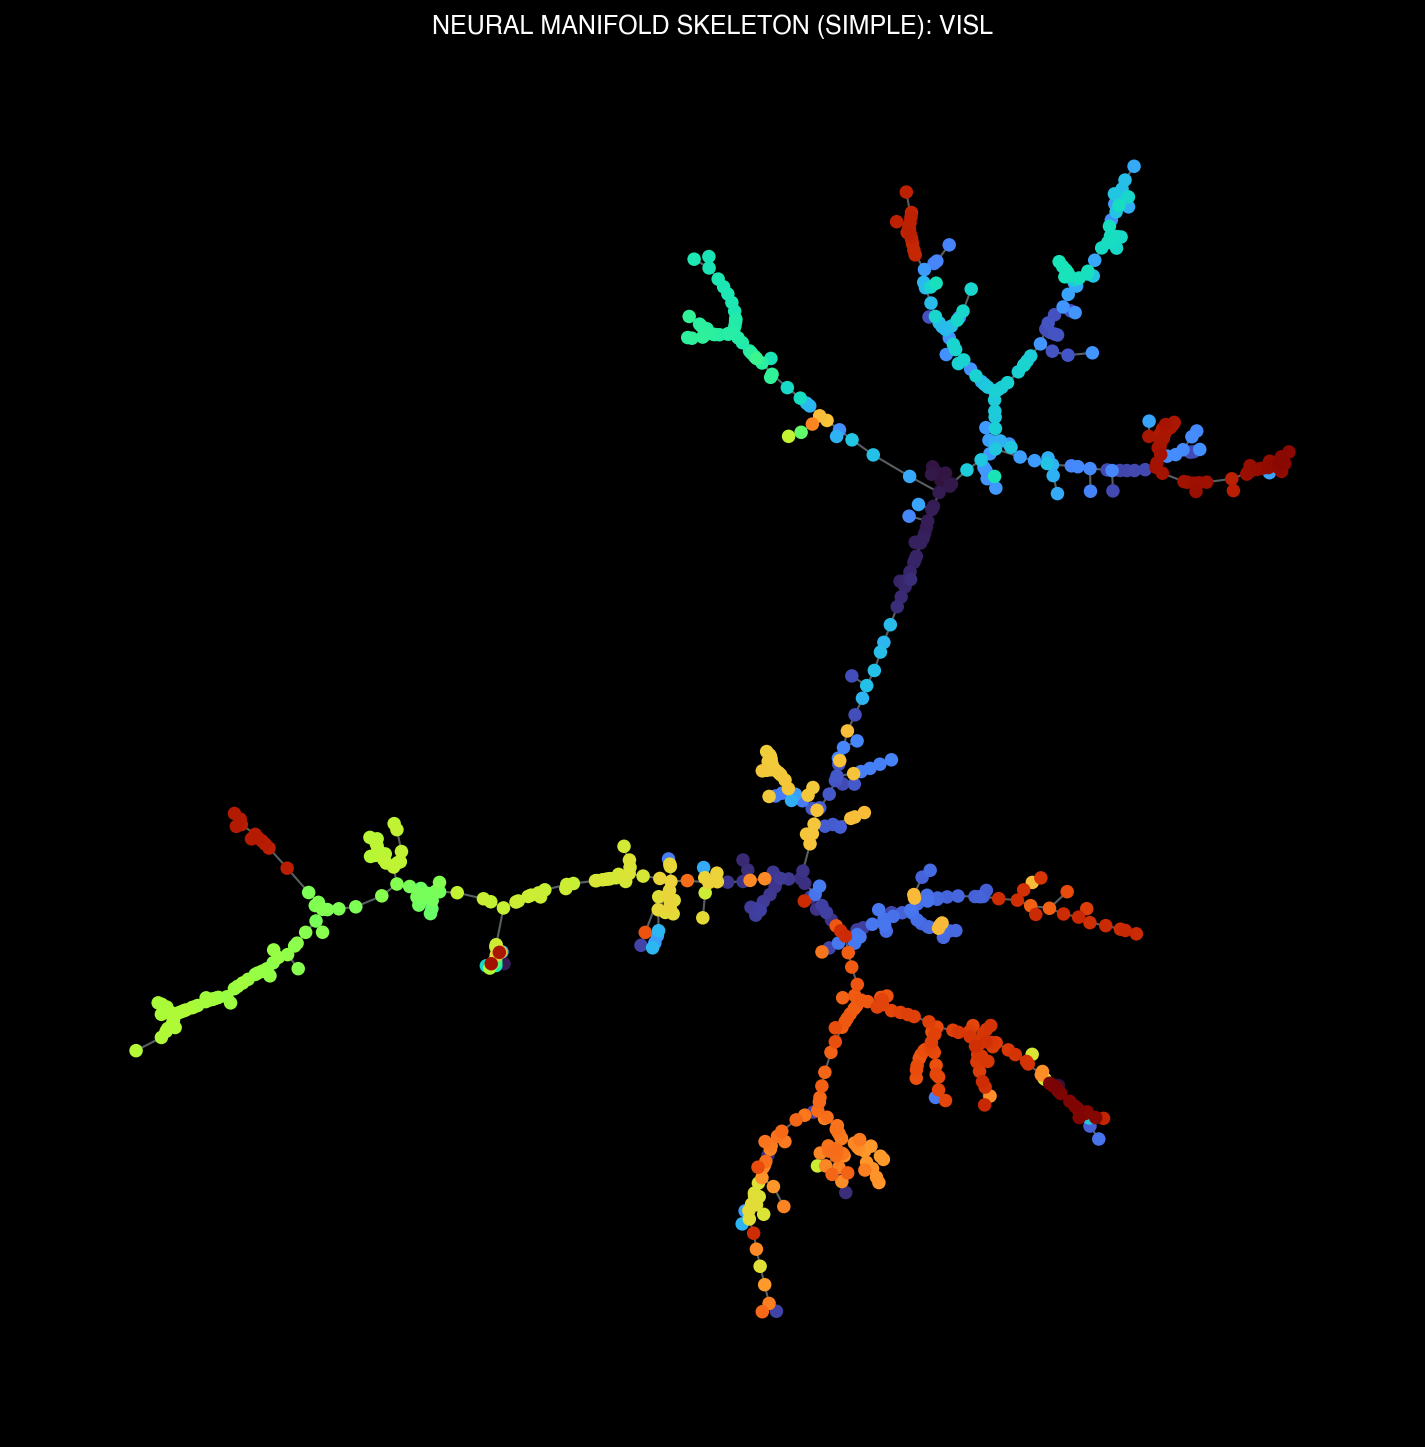


STARTING SIMPLE SKELETON PLOT FOR: VISrl
Saved simple skeleton to: ../Results/TDA_Iteration/4_1Simple_Manifold_Skeleton/VISrl.png


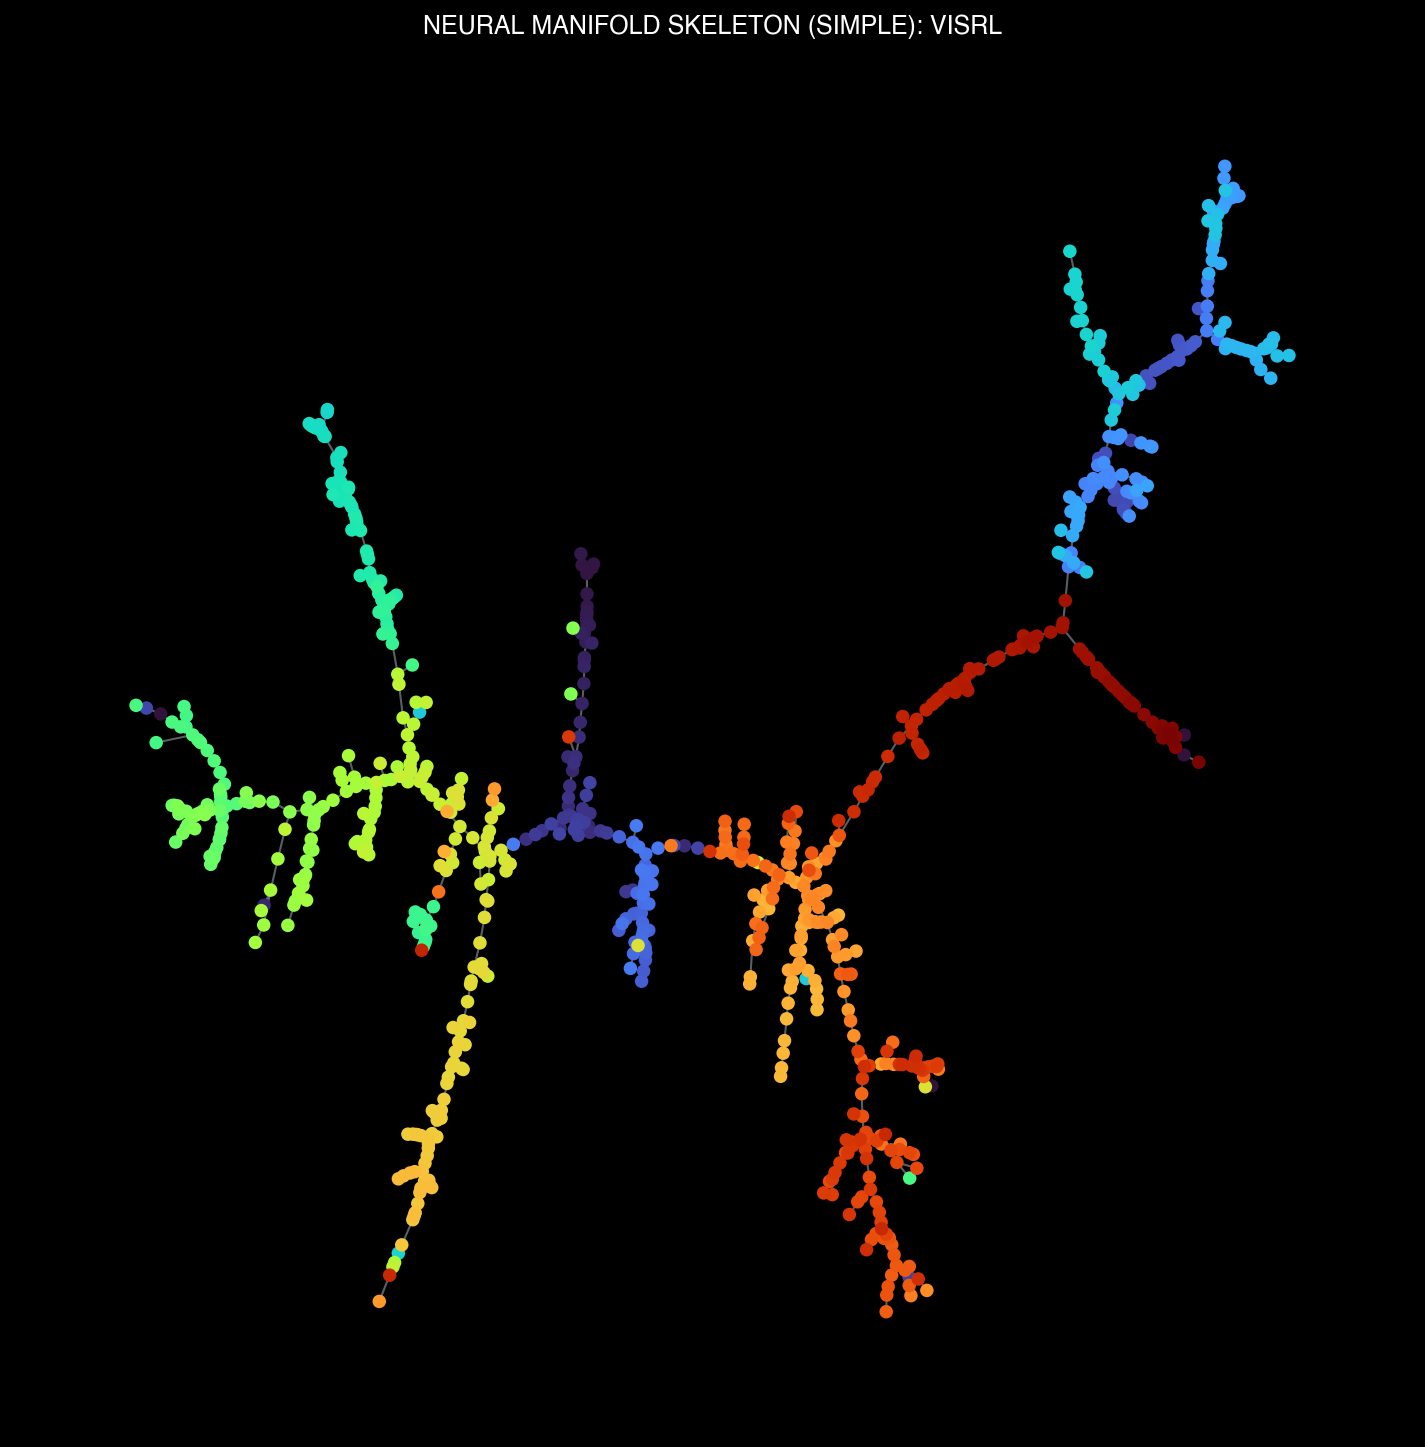

In [ ]:
# 3. Run Simple Skeleton Analysis
import simple_skeleton_plot
importlib.reload(simple_skeleton_plot) # Ensure we have the latest version

# Get all valid regions
valid_regions = [r for r in session.units["ecephys_structure_acronym"].unique() if isinstance(r, str)]
print(f"Found regions: {valid_regions}")

# Run the pipeline for each region
for region in valid_regions:
    try:
        simple_skeleton_plot.run_tda_pipeline_simple(session, region)
    except Exception as e:
        print(f"Error processing {region}: {e}")